# Construire un réseau de convolutions (CNN) pour tester trois classes

In [9]:
import os
from os import listdir
from os.path import isfile, join
import numpy as np
import pandas as pd
import random
import zipfile

import matplotlib.pyplot as plt
import seaborn as sns
import cv2

from sklearn.datasets import make_moons
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
import joblib

import tensorflow as tf
from tensorflow.keras import Input, Model
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# Pour définir la graine tout de suite
np.random.seed(42)
tf.random.set_seed(42)

print(tf.__version__)

2026-03-26 12:06:20.499212: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-26 12:06:20.504301: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-26 12:06:20.552241: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-26 12:06:20.597060: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774523180.638559    6387 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774523180.65

2.18.0


In [10]:
# Cellule générée par ChatGPT

def plot_history_simple(history):
    """
    Trace côte à côte les courbes Loss et Accuracy (train/val si dispo)
    à partir d'un objet Keras History.
    """
    hist = history.history

    # compatibilité anciennes versions ("acc"/"val_acc")
    acc_key = "accuracy" if "accuracy" in hist else "acc"
    val_acc_key = "val_accuracy" if "val_accuracy" in hist else "val_acc"

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # --- Loss ---
    if "loss" in hist:
        axes[0].plot(hist["loss"], label="train")
    if "val_loss" in hist:
        axes[0].plot(hist["val_loss"], label="val")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    # --- Accuracy ---
    if acc_key in hist:
        axes[1].plot(hist[acc_key], label="train")
        if val_acc_key in hist:
            axes[1].plot(hist[val_acc_key], label="val")
        axes[1].set_title("Accuracy")
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel("Accuracy")
        axes[1].legend()
    else:
        axes[1].set_visible(False)  # si pas d'accuracy, on masque le 2e plot

    plt.tight_layout()
    plt.show()



def plot_confusion_matrix_simple(y_true, y_pred, labels=(0,1),
                                 normalize=None, title="Confusion matrix"):
    """
    Affiche une matrice de confusion.
    Args:
        y_true, y_pred : vecteurs de labels
        labels         : ordre des classes à afficher
        normalize      : None, 'true', 'pred', ou 'all' (comme scikit-learn)
        title          : titre de la figure
    """
    cm = confusion_matrix(y_true, y_pred, labels=labels, normalize=normalize)
    fig, ax = plt.subplots(1, 1, figsize=(4, 4))
    im = ax.imshow(cm, interpolation='nearest')
    ax.figure.colorbar(im, ax=ax)

    ax.set(
        xticks=np.arange(len(labels)),
        yticks=np.arange(len(labels)),
        xticklabels=labels,
        yticklabels=labels,
        xlabel="Predicted label",
        ylabel="True label",
      title=title if normalize is None else f"{title} (normalized: {normalize})"
    )

    # annotations
    thresh = cm.max() / 2.0 if cm.size else 0.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            txt = f"{cm[i, j]:.2f}" if normalize else f"{int(cm[i, j])}"
            ax.text(j, i, txt,
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.show()

def plot_history_cv_mean_std(all_histories, alpha=0.2):
    """
    all_histories : list[pd.DataFrame]
        Chaque DF doit contenir : ['accuracy','loss','val_accuracy','val_loss','epoch','fold'].
        (c'est exactement ton format actuel)

    Trace loss et accuracy (train/val) avec moyenne ± écart-type par epoch.
    Si certains folds s'arrêtent plus tôt (early stopping), la moyenne/STD
    sur les dernières époques est calculée sur les folds encore présents.
    """
    import pandas as pd
    import matplotlib.pyplot as plt

    # 1) Concat & agrégation
    df = pd.concat(all_histories, ignore_index=True)
    cols = [c for c in ["loss", "val_loss", "accuracy", "val_accuracy"] if c in df.columns]
    stats = df.groupby("epoch")[cols].agg(["mean", "std"])
    stats.columns = [f"{m}_{s}" for m, s in stats.columns]  # ex: ('loss','mean')->'loss_mean'
    stats = stats.reset_index()
    epochs = stats["epoch"].values

    # 2) Plot côte à côte
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # --- Loss ---
    if "loss_mean" in stats:
        axes[0].plot(epochs, stats["loss_mean"], label="train")
        if "loss_std" in stats:
            axes[0].fill_between(epochs, stats["loss_mean"]-stats["loss_std"],
                                          stats["loss_mean"]+stats["loss_std"], alpha=alpha)
    if "val_loss_mean" in stats:
        axes[0].plot(epochs, stats["val_loss_mean"], label="val")
        if "val_loss_std" in stats:
            axes[0].fill_between(epochs, stats["val_loss_mean"]-stats["val_loss_std"],
                                          stats["val_loss_mean"]+stats["val_loss_std"], alpha=alpha)
    axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend()

    # --- Accuracy ---
    if "accuracy_mean" in stats:
        axes[1].plot(epochs, stats["accuracy_mean"], label="train")
        if "accuracy_std" in stats:
            axes[1].fill_between(epochs, stats["accuracy_mean"]-stats["accuracy_std"],
                                          stats["accuracy_mean"]+stats["accuracy_std"], alpha=alpha)
    if "val_accuracy_mean" in stats:
        axes[1].plot(epochs, stats["val_accuracy_mean"], label="val")
        if "val_accuracy_std" in stats:
            axes[1].fill_between(epochs, stats["val_accuracy_mean"]-stats["val_accuracy_std"],
                                          stats["val_accuracy_mean"]+stats["val_accuracy_std"], alpha=alpha)
    axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].legend()

    plt.tight_layout()
    plt.show()

def plot_decision_boundary(pipe, X, y=None, title=None, h=0.02, padding=0.5, threshold=0.5, ax=None):
    """
    Affiche la frontière de décision d'un modèle 2D (ex: make_moons).
    pipe : Pipeline déjà fit (ex: StandardScaler + KerasClassifier)
    X, y : données à superposer (y optionnel pour juste la frontière)
    h : pas de la grille, padding : marge autour des données
    threshold : seuil de classification si proba disponible
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(6,5))

    # -- Grille 2D
    x_min, x_max = X[:,0].min()-padding, X[:,0].max()+padding
    y_min, y_max = X[:,1].min()-padding, X[:,1].max()+padding
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    grid = np.c_[xx.ravel(), yy.ravel()]

    # -- Prédiction robuste (proba > decision_function > predict)
    Z = None
    if hasattr(pipe, "predict_proba"):
        proba = pipe.predict_proba(grid)
        # binaire : colonnes [p(classe0), p(classe1)] ou vecteur
        Z = proba[:,1] if proba.ndim == 2 and proba.shape[1] > 1 else proba.ravel()
    elif hasattr(pipe, "decision_function"):
        s = pipe.decision_function(grid).ravel()
        # Normalisation sigmoïde légère sans SciPy
        Z = 1 / (1 + np.exp(-s))
    else:
        # chute de secours : classes {0,1}
        Z = pipe.predict(grid).ravel().astype(float)

    Z_grid = Z.reshape(xx.shape)

    # -- Fond coloré + ligne de frontière
    # si Z est proba, on trace la courbe de niveau au seuil; sinon on sépare 0/1
    if np.unique(Z).size > 2 or (Z.min() >= 0 and Z.max() <= 1):
        ax.contourf(xx, yy, Z_grid, levels=50, alpha=0.25)
        ax.contour(xx, yy, (Z_grid >= threshold).astype(int), levels=[0.5], colors="k", linewidths=1)
    else:
        ax.contourf(xx, yy, Z_grid, levels=[-0.5,0.5,1.5], alpha=0.25)
        ax.contour(xx, yy, Z_grid, levels=[0.5], colors="k", linewidths=1)

    # -- Nuage de points (si y fourni)
    if y is not None:
        ax.scatter(X[:,0], X[:,1], c=y, s=25, edgecolor="k", linewidth=0.5)

    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    if title:
        ax.set_title(title)
    ax.set_aspect("equal", adjustable="box")
    plt.tight_layout()
    return ax

def plot_examples(X,y,nb_columns=25):
  plt.figure(figsize=(15,15))
  for i in range(nb_columns):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    # cv2 lit met les images en BGR et matplotlib lit du RGB
    X[i] = cv2.cvtColor(X[i], cv2.COLOR_BGR2RGB)
    plt.imshow(X[i]/255.,cmap=plt.cm.binary)
    plt.xlabel('classe ' + str(y[i]))

In [12]:
zip_files=["Data_sheep_cat_elephant_with_caption_200.zip",
    "Data_sheep_cat_elephant_with_caption_400.zip",
    "Data_sheep_cat_elephant_with_caption_600.zip"]

for file in zip_files:
    !wget https://www.lirmm.fr/~poncelet/Ressources/{file}
    
    with zipfile.ZipFile(file, "r") as zip_ref:
        zip_ref.extractall("Data_Project")

    os.remove(file)

--2026-03-26 12:10:35--  https://www.lirmm.fr/~poncelet/Ressources/Data_sheep_cat_elephant_with_caption_200.zip
Résolution de www.lirmm.fr (www.lirmm.fr)… 193.49.104.251
Connexion à www.lirmm.fr (www.lirmm.fr)|193.49.104.251|:443… connecté.
requête HTTP transmise, en attente de la réponse… 200 OK
Taille : 115482858 (110M) [application/zip]
Enregistre : ‘Data_sheep_cat_elephant_with_caption_200.zip’

Data_sheep_cat_elep 100%[===================>] 110,13M  8,66MB/s    ds 10s     

2026-03-26 12:10:47 (10,9 MB/s) - ‘Data_sheep_cat_elephant_with_caption_200.zip’ enregistré [115482858/115482858]

--2026-03-26 12:10:47--  https://www.lirmm.fr/~poncelet/Ressources/Data_sheep_cat_elephant_with_caption_400.zip
Résolution de www.lirmm.fr (www.lirmm.fr)… 193.49.104.251
Connexion à www.lirmm.fr (www.lirmm.fr)|193.49.104.251|:443… connecté.
requête HTTP transmise, en attente de la réponse… 200 OK
Taille : 230167099 (220M) [application/zip]
Enregistre : ‘Data_sheep_cat_elephant_with_caption_400.zip’

# Resize images

In [19]:
IMG_SIZE=128
mypaths=['Data_Project/images/elephant', 'Data_Project/images/cat', 'Data_Project/images/sheep']

for path in mypaths:
    onlyfiles = [ f for f in listdir(path) if isfile(join(path,f)) ]
    images = np.empty(len(onlyfiles), dtype=object)
    for n in range(0, len(onlyfiles)):
        images[n] = cv2.imread( join(path,onlyfiles[n]) )
        images[n]  = cv2.resize(images[n], (IMG_SIZE, IMG_SIZE))

In [23]:
#there is a slight modification from the code we copied 
def create_training_data(path_data, list_classes):
  training_data=[]
  for classes in list_classes:
      path=os.path.join(path_data, classes)
      class_num=list_classes.index(classes)
      for img in os.listdir(path):
        try:
          img_array = cv2.imread(os.path.join(path,img), cv2.IMREAD_COLOR) #we can read colors now forcing 3 channels
          new_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
          training_data.append([new_array, class_num])
        except Exception as e:
          pass
  return training_data

def create_X_y (path_data, list_classes):
      # récupération des données
      training_data=create_training_data(path_data, list_classes)
      # tri des données
      random.shuffle(training_data)
      # création de X et y
      X=[]
      y=[]
      for features, label in training_data:
        X.append(features)
        y.append(label)
      X=np.array(X).reshape(-1,IMG_SIZE, IMG_SIZE, 3)
      y=np.array(y)
      return X,y

# Loading the classes

Nombre de données : 1800
Taille d'une image : (128, 128, 3)
Distribution des classes :
2    600
1    600
0    600
Name: count, dtype: int64


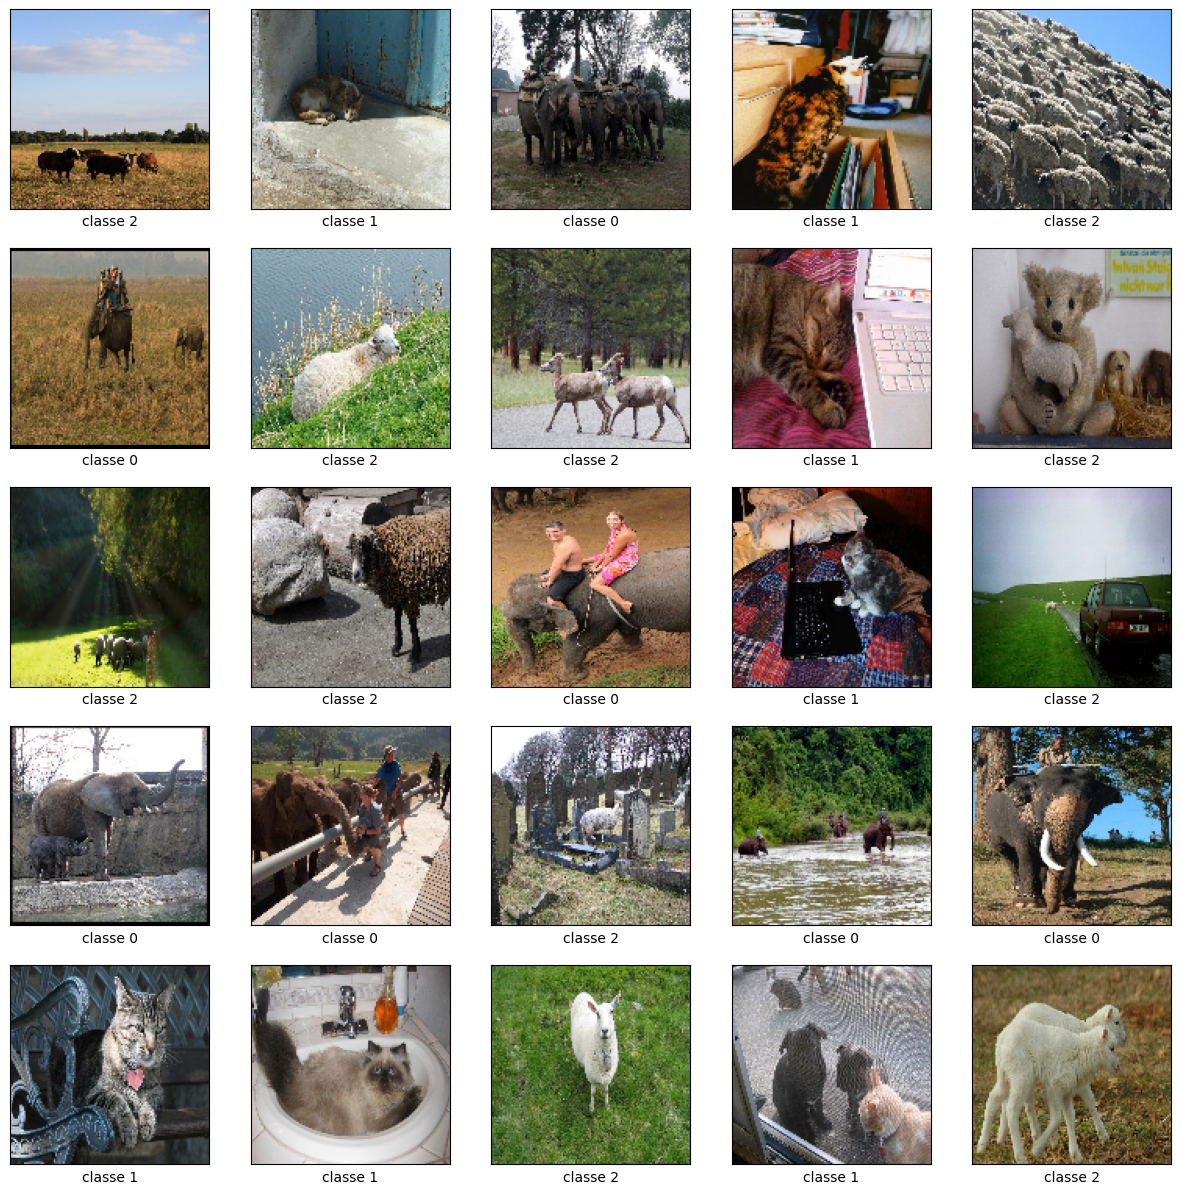

In [65]:
my_path = "Data_Project/images/"          
my_classes = ['elephant', 'cat', 'sheep']  

X, y = create_X_y(my_path, my_classes)

plot_examples(X, y)

print("Nombre de données :", X.shape[0])
print("Taille d'une image :", X[0].shape)
print("Distribution des classes :")
print(pd.Series(y).value_counts())

# Normalize data 

In [66]:
X=X.astype('float')
X=X/255.0

# Building the CNN model

In [49]:
image_size=128


input = Input(shape=(image_size, image_size, 3), name="Input_layer")
x = Conv2D(32, (3, 3), activation="relu", name="Conv2D_1")(input)
x = MaxPooling2D(pool_size=(2, 2), name="MaxPool2D_1")(x)
x = Flatten(name="Flatten")(x)
x = Dense(64, activation="relu", name="dense_1")(x)

output = Dense(3, activation="softmax", name="Output_Layer")(x)

model = Model(inputs=input, outputs=output, name="Baseline_CNN")

# Compiling the Model

In [50]:
model.compile(optimizer=Adam(1e-3),
              loss="sparse_categorical_crossentropy", #categoral entropy doesn't work, forgot i needed the data to be encoded :(
              metrics=["accuracy"])

In [51]:
model.summary()

Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2D_1 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPool2D_1 (MaxPooling2D)      │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Flatten (Flatten)               │ (None, 127008)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │     8,128,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,129,667 (31.01 MB)

 Trainable params: 8,129,667 (31.01 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - accuracy: 0.3932 - loss: 5.3125 - val_accuracy: 0.4722 - val_loss: 1.0565
Epoch 2/40
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step - accuracy: 0.5964 - loss: 0.8854 - val_accuracy: 0.6771 - val_loss: 0.7763
Epoch 3/40
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - accuracy: 0.7413 - loss: 0.6744 - val_accuracy: 0.6910 - val_loss: 0.7301
Epoch 4/40
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - accuracy: 0.8342 - loss: 0.4816 - val_accuracy: 0.7083 - val_loss: 0.7228
Epoch 5/40
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - accuracy: 0.9054 - loss: 0.3410 - val_accuracy: 0.6944 - val_loss: 0.7498
Epoch 6/40
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step - accuracy: 0.9306 - loss: 0.2776 - val_accuracy: 0.6806 - val_loss: 0.7864
Epoch 7/40
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - accuracy: 0.9002 - loss: 0.2964 - val_accuracy: 0.4514 - val_loss: 1.5112
Epoch 8/40
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step - accuracy: 0.9089 - loss: 0.2989 - val_accuracy: 0.6493 - v

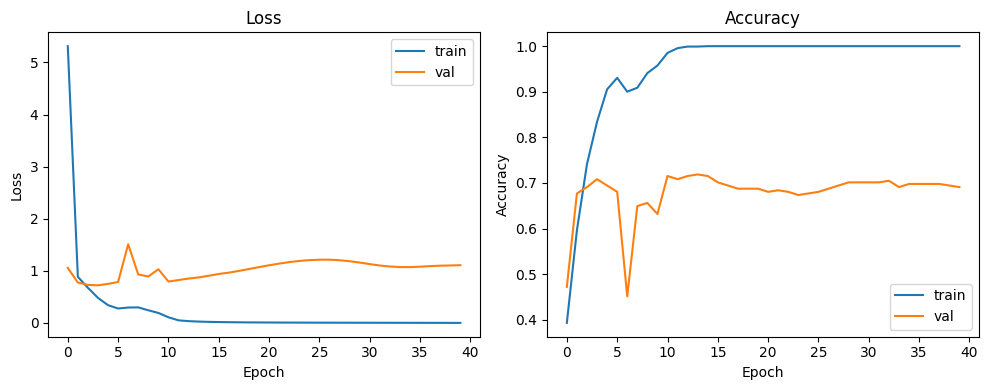

Test accuracy: 0.672


In [52]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Entraînement
epochs = 40
batch_size = 32
history = model.fit(
    X_train, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.2,
    verbose=1
)

# Courbes loss/accuracy
plot_history_simple(history)

# Évaluation sur X_test
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print("Test accuracy:", round(test_acc, 3))

# Conclusion
Le model montre des signes de overfitting, la courbe de la fonction de perte pour l'entraînement continue de baîsser tandis que
celle pour le jeu de test cesse de diminuer autour l'epoch 4. et pour la courbe de l'accuracy on observe pour celle de jeu de test
qu'elle n'augmante après l'epoch 10.

## Solution :
###            1) augmentation de données 
###            2) Réglage du modèle (ajout de dropout,...ect)
###            3)Transfer learning

# Réglage du modèle 

### 1er essai

In [62]:
from tensorflow.keras import regularizers
from tensorflow.keras.layers import Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import SGD 
image_size=128


input = Input(shape=(image_size, image_size, 3), name="Input_layer")
x = Conv2D(32, (3, 3), activation="relu", padding="same", name="Conv2D_1")(input)
x = MaxPooling2D(pool_size=(2, 2), name="MaxPool2D_1")(x)
x = Conv2D(64, (3, 3), activation="relu", padding="same", name="Conv2D_2")(x)
x = MaxPooling2D(pool_size=(2, 2), name="MaxPool2D_2")(x)
x = Flatten(name="Flatten")(x)
x = Dense(64, activation="relu", kernel_regularizer=regularizers.l2(0.01), name="dense_1")(x)
x = Dropout(0.5)(x)

output = Dense(3, activation="softmax", name="Output_Layer")(x)

model = Model(inputs=input, outputs=output, name="Deeper_CNN")

In [63]:
opt = SGD(learning_rate=0.01, momentum=0.9)
model.compile(optimizer=opt,
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

In [64]:
model.summary()

Model: "Deeper_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2D_1 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPool2D_1 (MaxPooling2D)      │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2D_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPool2D_2 (MaxPooling2D)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Flatten (Flatten)               │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │     4,194,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,955 (16.07 MB)

 Trainable params: 4,213,955 (16.07 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 111ms/step - accuracy: 0.3490 - loss: 2.3799 - val_accuracy: 0.3715 - val_loss: 2.2686
Epoch 2/40
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 109ms/step - accuracy: 0.3767 - loss: 2.1969 - val_accuracy: 0.4132 - val_loss: 2.1029
Epoch 3/40
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 108ms/step - accuracy: 0.4062 - loss: 2.0356 - val_accuracy: 0.3576 - val_loss: 1.9684
Epoch 4/40
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 112ms/step - accuracy: 0.3785 - loss: 1.9075 - val_accuracy: 0.4549 - val_loss: 1.8356
Epoch 5/40
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 111ms/step - accuracy: 0.4262 - loss: 1.7784 - val_accuracy: 0.4201 - val_loss: 1.7119
Epoch 6/40
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 110ms/step - accuracy: 0.4366 - loss: 1.6762 - val_accuracy: 0.4896 - val_loss: 1.6175
Epoch 7/40
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 109ms/step - accuracy: 0.4514 - loss: 1.5827 - val_accuracy: 0.5417 - val_loss: 1.4688
Epoch 8/40
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 110ms/step - accuracy: 0.5026 - loss: 1.4613 - val_accuracy: 0.

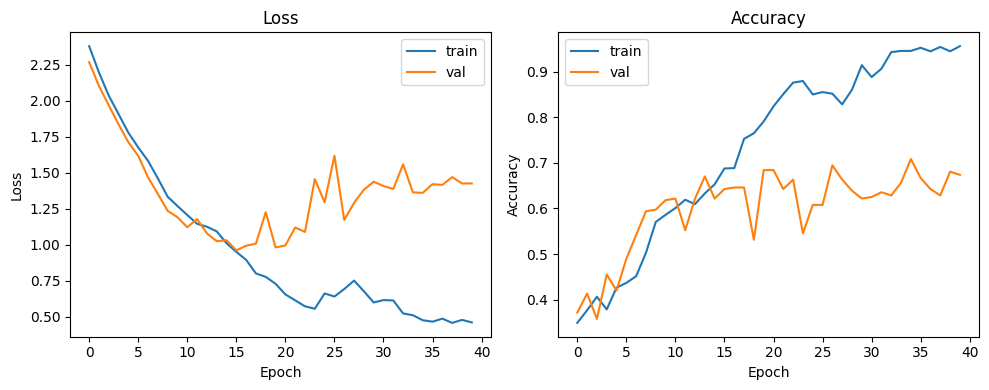

Test accuracy: 0.703


In [61]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Entraînement
epochs = 40
batch_size = 32
history = model.fit(
    X_train, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.2,
    verbose=1
)

# Courbes loss/accuracy
plot_history_simple(history)

# Évaluation sur X_test
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print("Test accuracy:", round(test_acc, 3))

# Conclusion

le modèle prouve d'être mieux que le baseline mais il montre quelque signes de sur-apprentissage (la courbe d'accuracy, pour celle d'entraînement on remarque qu'elle converge vers la valeur 1 même si celle de validation plafonne environ 0.7, on observe des oscillation à partir de l'epoch 10 indiquant que la validation est trop petite). Ce modèle reste limité.

### 2ème essai

In [67]:
from tensorflow.keras import regularizers
from tensorflow.keras.layers import Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.layers import BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

image_size=128


input = Input(shape=(image_size, image_size, 3), name="Input_layer")

x = Conv2D(32, (3, 3), activation="relu", padding="same", name="Conv2D_1")(input)
x = BatchNormalization(name="BN_1")(x)
x = MaxPooling2D(pool_size=(2, 2), name="MaxPool2D_1")(x)

#deepening my network

x = Conv2D(64, (3, 3), activation="relu", padding="same", name="Conv2D_2")(x)
x = BatchNormalization(name="BN_2")(x)
x = MaxPooling2D(pool_size=(2, 2), name="MaxPool2D_2")(x)

x = GlobalAveragePooling2D(name="GAP")(x)
x = Dense(64, activation="relu", kernel_regularizer=regularizers.l2(0.01), name="dense_1")(x)
x = Dropout(0.5)(x)

output = Dense(3, activation="softmax", name="Output_Layer")(x)

model = Model(inputs=input, outputs=output, name="Improved_CNN")

In [68]:
opt = SGD(learning_rate=0.01, momentum=0.9)
model.compile(optimizer=opt,
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

In [69]:
model.summary()

Model: "Improved_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2D_1 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BN_1 (BatchNormalization)       │ (None, 128, 128, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPool2D_1 (MaxPooling2D)      │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2D_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BN_2 (BatchNormalization)       │ (None, 64, 64, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPool2D_2 (MaxPooling2D)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ GAP (GlobalAveragePooling2D)    │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,131 (94.26 KB)

 Trainable params: 23,939 (93.51 KB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/40
36/36 ━━━━━━━━━━━━━━━━━━━━ 9s 222ms/step - accuracy: 0.5069 - loss: 1.6768 - val_accuracy: 0.3681 - val_loss: 1.6828 - learning_rate: 0.0100
Epoch 2/40
36/36 ━━━━━━━━━━━━━━━━━━━━ 8s 210ms/step - accuracy: 0.5642 - loss: 1.4685 - val_accuracy: 0.3785 - val_loss: 1.6026 - learning_rate: 0.0100
Epoch 3/40
36/36 ━━━━━━━━━━━━━━━━━━━━ 8s 214ms/step - accuracy: 0.5738 - loss: 1.3557 - val_accuracy: 0.3819 - val_loss: 1.5237 - learning_rate: 0.0100
Epoch 4/40
36/36 ━━━━━━━━━━━━━━━━━━━━ 8s 218ms/step - accuracy: 0.5877 - loss: 1.2921 - val_accuracy: 0.3542 - val_loss: 1.4875 - learning_rate: 0.0100
Epoch 5/40
36/36 ━━━━━━━━━━━━━━━━━━━━ 8s 222ms/step - accuracy: 0.5998 - loss: 1.2195 - val_accuracy: 0.3646 - val_loss: 1.4243 - learning_rate: 0.0100
Epoch 6/40
36/36 ━━━━━━━━━━━━━━━━━━━━ 8s 214ms/step - accuracy: 0.6181 - loss: 1.1730 - val_accuracy: 0.4167 - val_loss: 1.2868 - learning_rate: 0.0100
Epoch 7/40
36/36 ━━━━━━━━━━━━━━━━━━━━ 8s 218ms/step - accuracy: 0.6207 - loss: 1.1146 - 

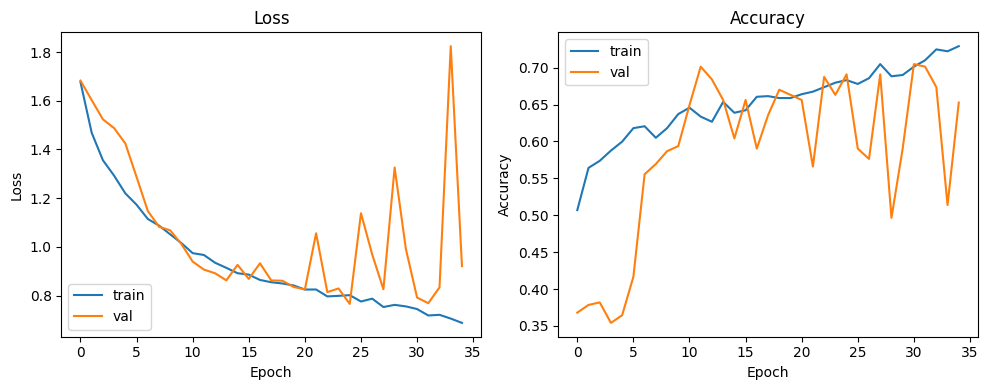

Test accuracy: 0.694


In [70]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

es = EarlyStopping(monitor="val_loss", patience=10,
                   restore_best_weights=True, verbose=1)

rlrop = ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                          patience=5, min_lr=1e-6, verbose=1)
# Entraînement
epochs = 40
batch_size = 32
history = model.fit(
    X_train, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.2,
    callbacks=[es, rlrop],
    verbose=1
)

# Courbes loss/accuracy
plot_history_simple(history)

# Évaluation sur X_test
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print("Test accuracy:", round(test_acc, 3))

In [71]:
#hmmmmmmm

# Conclusion

Le modèle ,même amélioré, reste limité par la taille du dataset. Avec seulement 1 440 images d'entraînement (80%) et ~288 pour la validation (20% du train_split), chaque batch de validation est peu représentatif, d'où les oscillations.